<ipython-input-1-d88997a43092>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['age', 'fare']] = num_imputer.fit_transform(df[['age', 'fare']])
<ipython-input-1-d88997a43092>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['embarked']] = cat_imputer.fit_transform(df[['embarked']])
<ipython-input-1-d88997a43092>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

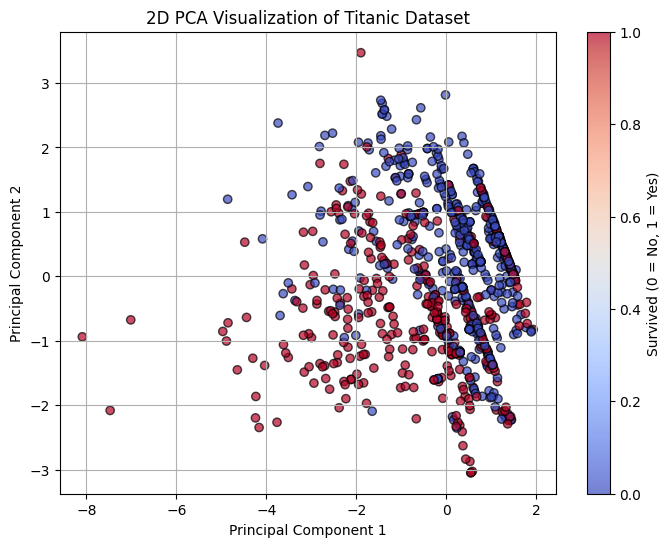

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from mpl_toolkits.mplot3d import Axes3D # Import for 3D plotting

# Step 1: Load Titanic Dataset from OpenML (Using sklearn)
titanic = fetch_openml(name='titanic', version=1, as_frame=True)

# Convert data to DataFrame
df = titanic.data
df['survived'] = titanic.target.astype(int) # Ensure target is in dataset

# Select relevant features for machine learning
df = df[['pclass', 'sex', 'age', 'fare', 'embarked', 'survived']]

# Step 2: Handle Missing Data
## 2.1 Impute missing numerical values with the mean
num_imputer = SimpleImputer(strategy='mean')
df[['age', 'fare']] = num_imputer.fit_transform(df[['age', 'fare']])

## 2.2 Impute missing categorical values with the most frequent value (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[['embarked']] = cat_imputer.fit_transform(df[['embarked']])

# Step 3: Encode Categorical Data (Convert text labels into numbers)
label_encoder = LabelEncoder()
df['sex'] = label_encoder.fit_transform(df['sex']) # Male=1, Female=0
df['embarked'] = label_encoder.fit_transform(df['embarked']) # C, Q, S → 0,1,2

# Step 4: Define Features (X) and Target (y)
X = df.drop(columns=["survived"]) # Features
y = df["survived"] # Target variable (0 = Did not survive, 1 = Survived)

# Step 5: Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Feature Scaling (Standardizing numerical features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Apply PCA - Reduce to 3 Components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_scaled)

# Step 8: 2D Visualization of PCA Components
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization of Titanic Dataset")
plt.colorbar(label="Survived (0 = No, 1 = Yes)")
plt.grid(True)
plt.show()

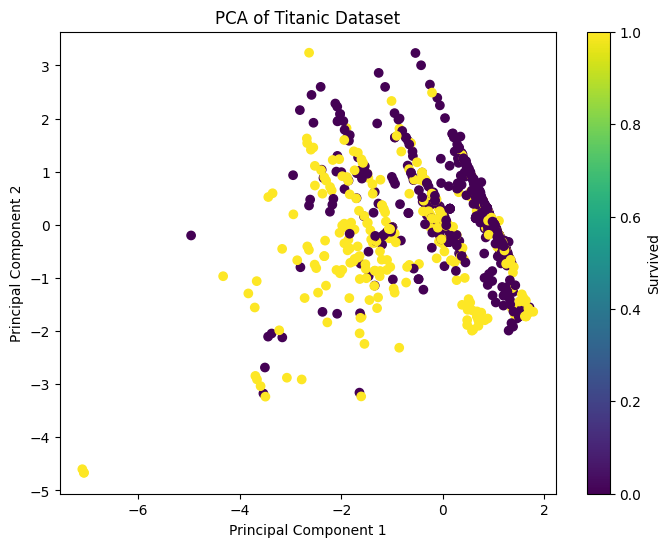

Explained Variance Ratio: [0.56156729 0.30646255]


In [3]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load the Titanic dataset from seaborn
titanic_data = sns.load_dataset('titanic')

# 2. Select features for PCA
features = ['age', 'fare', 'pclass']
X = titanic_data[features]

# 3. Handle missing values (if any)
X = X.fillna(X.mean())

# 4. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=titanic_data['survived'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Titanic Dataset')
plt.colorbar(label='Survived')
plt.show()

# 7. Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance}")